# MovieLens-1M 数据分析报告

本 Notebook 对 MovieLens-1M 数据集进行全面的探索性数据分析（EDA），包括基本统计信息和多维度可视化。

In [1]:
import sys
import os
# 确保工作目录为项目根目录 pomelo/
if os.path.basename(os.getcwd()) == 'experiments':
    os.chdir('..')
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

from src.data.loader import load_ratings, load_movies, load_users
from src.data.analyzer import compute_statistics

print(f'Working directory: {os.getcwd()}')
print('Imports OK')

Working directory: D:\课件\大数据处理技术\demo\pomelo
Imports OK


## 1. 数据加载

In [2]:
ratings = load_ratings()
movies = load_movies()
users = load_users()

print(f'Ratings shape: {ratings.shape}')
print(f'Movies shape: {movies.shape}')
print(f'Users shape: {users.shape}')

ratings.head()

[2026-04-16 21:39:01] src.data.loader - INFO - Loading ratings from D:\课件\大数据处理技术\demo\pomelo\data\raw\ml-1m\ratings.dat


[2026-04-16 21:39:03] src.data.loader - INFO - Loaded 1000209 ratings


[2026-04-16 21:39:03] src.data.loader - INFO - Loading movies from D:\课件\大数据处理技术\demo\pomelo\data\raw\ml-1m\movies.dat


[2026-04-16 21:39:03] src.data.loader - INFO - Loaded 3883 movies


[2026-04-16 21:39:03] src.data.loader - INFO - Loading users from D:\课件\大数据处理技术\demo\pomelo\data\raw\ml-1m\users.dat


[2026-04-16 21:39:03] src.data.loader - INFO - Loaded 6040 users


Ratings shape: (1000209, 4)
Movies shape: (3883, 3)
Users shape: (6040, 5)


,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [3]:
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [4]:
users.head()

,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


## 2. 基本统计信息

In [5]:
stats = compute_statistics(ratings, movies, users)

print('=' * 50)
print('MovieLens-1M Dataset Statistics')
print('=' * 50)
print(f"Users:              {stats['n_users']:,}")
print(f"Movies:             {stats['n_movies']:,}")
print(f"Ratings:            {stats['n_ratings']:,}")
print(f"Sparsity:           {stats['sparsity']:.4%}")
print(f"Avg ratings/user:   {stats['avg_ratings_per_user']:.1f}")
print(f"Avg ratings/movie:  {stats['avg_ratings_per_movie']:.1f}")
print(f"Rating mean:        {stats['rating_mean']:.2f}")
print(f"Rating std:         {stats['rating_std']:.2f}")

[2026-04-16 21:39:03] src.data.analyzer - INFO - Dataset Statistics:


[2026-04-16 21:39:03] src.data.analyzer - INFO -   n_users: 6040


[2026-04-16 21:39:03] src.data.analyzer - INFO -   n_movies: 3706


[2026-04-16 21:39:03] src.data.analyzer - INFO -   n_ratings: 1000209


[2026-04-16 21:39:03] src.data.analyzer - INFO -   sparsity: 0.9553


[2026-04-16 21:39:03] src.data.analyzer - INFO -   avg_ratings_per_user: 165.5975


[2026-04-16 21:39:03] src.data.analyzer - INFO -   avg_ratings_per_movie: 269.8891


[2026-04-16 21:39:03] src.data.analyzer - INFO -   rating_mean: 3.5816


[2026-04-16 21:39:03] src.data.analyzer - INFO -   rating_std: 1.1171


MovieLens-1M Dataset Statistics
Users:              6,040
Movies:             3,706
Ratings:            1,000,209
Sparsity:           95.5316%
Avg ratings/user:   165.6
Avg ratings/movie:  269.9
Rating mean:        3.58
Rating std:         1.12


## 3. 数据预处理结果

In [6]:
train = pd.read_csv('data/processed/train.csv')
val = pd.read_csv('data/processed/val.csv')
test = pd.read_csv('data/processed/test.csv')

total = len(train) + len(val) + len(test)
print(f'Train: {len(train):,} ({len(train)/total:.2%})')
print(f'Val:   {len(val):,} ({len(val)/total:.2%})')
print(f'Test:  {len(test):,} ({len(test)/total:.2%})')
print(f'Total: {total:,}')

Train: 987,531 (98.79%)
Val:   6,040 (0.60%)
Test:  6,040 (0.60%)
Total: 999,611


## 4. 可视化分析

### 4.1 用户活跃度分布

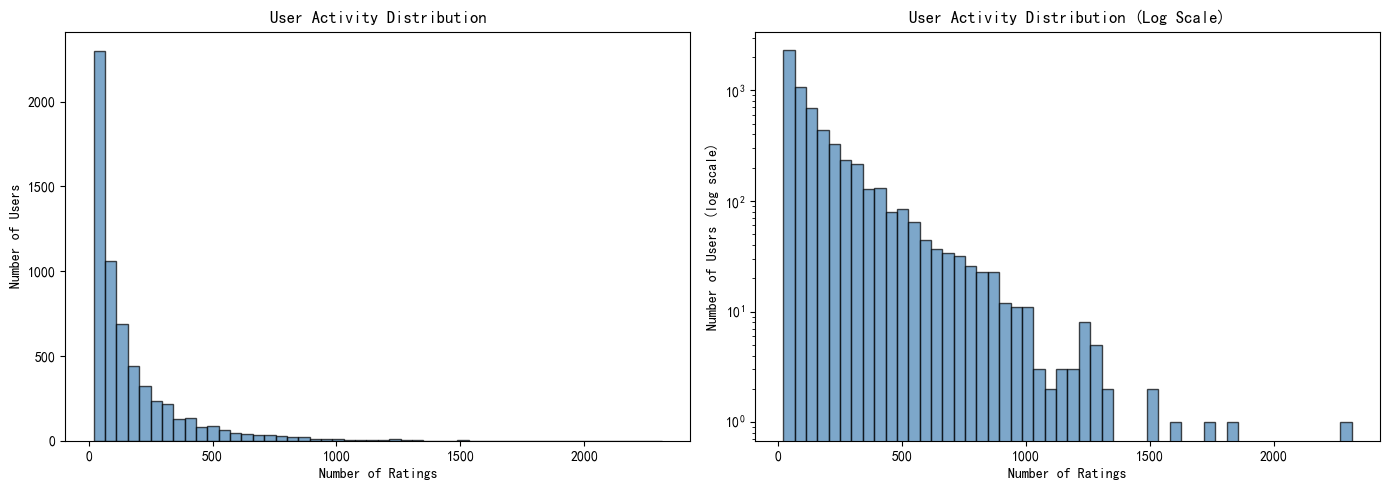

User activity stats:
  Min: 20, Max: 2314
  Mean: 165.6, Median: 96


In [7]:
save_dir = 'results/figures/data_analysis'
os.makedirs(save_dir, exist_ok=True)

# 用户活跃度分布
user_counts = ratings.groupby('user_id').size()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(user_counts, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')
axes[0].set_title('User Activity Distribution')

axes[1].hist(user_counts, bins=50, edgecolor='black', alpha=0.7, color='steelblue', log=True)
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users (log scale)')
axes[1].set_title('User Activity Distribution (Log Scale)')

plt.tight_layout()
fig.savefig(os.path.join(save_dir, 'user_activity_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'User activity stats:')
print(f'  Min: {user_counts.min()}, Max: {user_counts.max()}')
print(f'  Mean: {user_counts.mean():.1f}, Median: {user_counts.median():.0f}')

### 4.2 电影热门度分布

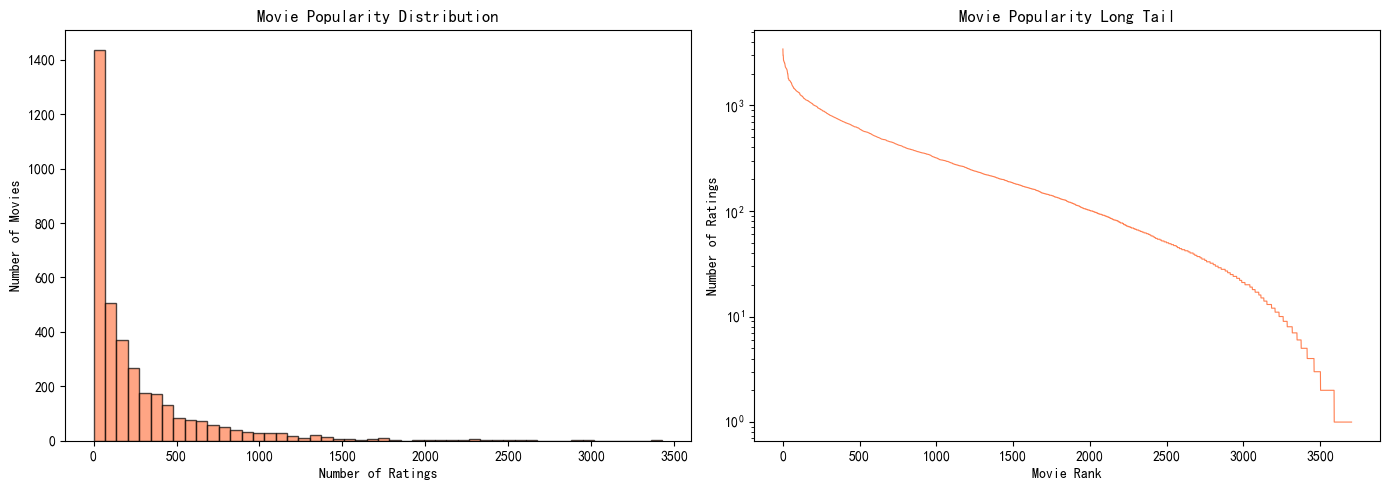

Movie popularity stats:
  Min: 1, Max: 3428
  Mean: 269.9, Median: 124


In [8]:
item_counts = ratings.groupby('movie_id').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(item_counts, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Movies')
axes[0].set_title('Movie Popularity Distribution')

axes[1].plot(range(len(item_counts)), item_counts.values, color='coral', linewidth=0.8)
axes[1].set_xlabel('Movie Rank')
axes[1].set_ylabel('Number of Ratings')
axes[1].set_title('Movie Popularity Long Tail')
axes[1].set_yscale('log')

plt.tight_layout()
fig.savefig(os.path.join(save_dir, 'item_popularity_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f'Movie popularity stats:')
print(f'  Min: {item_counts.min()}, Max: {item_counts.max()}')
print(f'  Mean: {item_counts.mean():.1f}, Median: {item_counts.median():.0f}')

### 4.3 评分分布

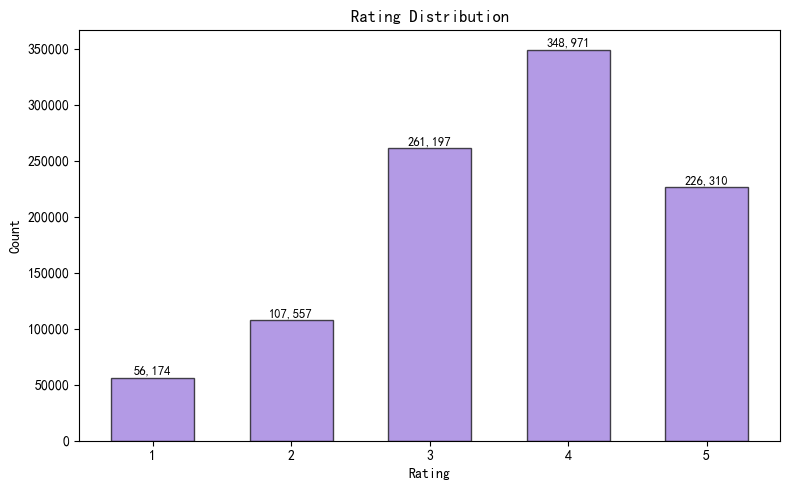

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))

rating_counts = ratings['rating'].value_counts().sort_index()
ax.bar(rating_counts.index, rating_counts.values, width=0.6,
       edgecolor='black', alpha=0.7, color='mediumpurple')
ax.set_xlabel('Rating')
ax.set_ylabel('Count')
ax.set_title('Rating Distribution')
ax.set_xticks([1, 2, 3, 4, 5])

for r, c in zip(rating_counts.index, rating_counts.values):
    ax.text(r, c + 1000, f'{c:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(save_dir, 'rating_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

### 4.4 电影类型分布

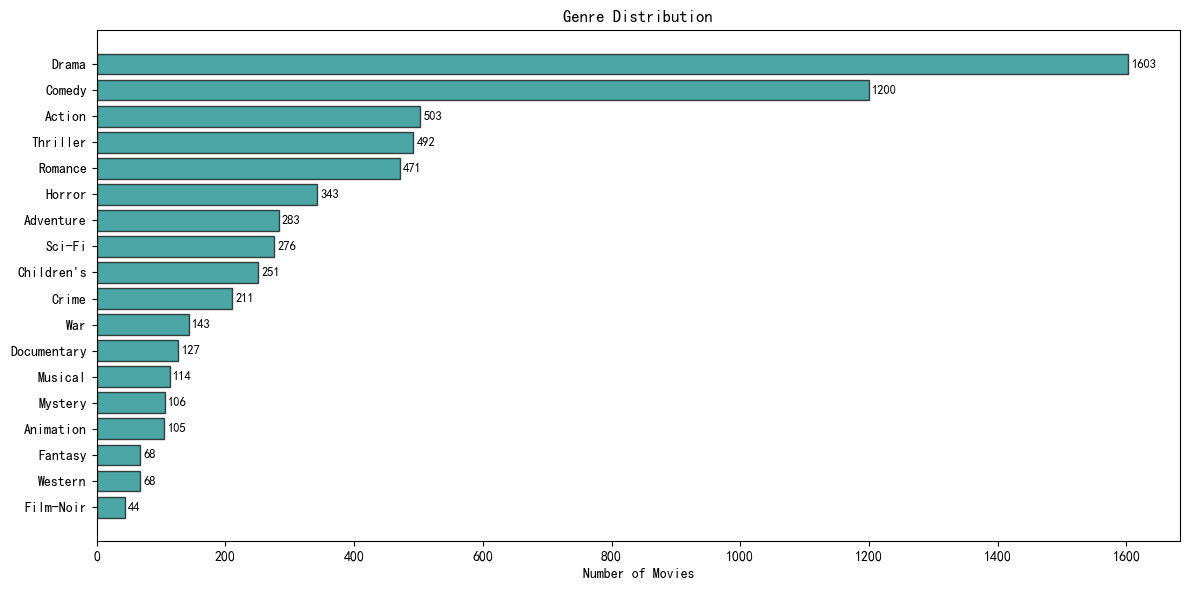

Genre counts:
genres
Drama          1603
Comedy         1200
Action          503
Thriller        492
Romance         471
Horror          343
Adventure       283
Sci-Fi          276
Children's      251
Crime           211
War             143
Documentary     127
Musical         114
Mystery         106
Animation       105
Fantasy          68
Western          68
Film-Noir        44


In [10]:
all_genres = movies['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(genre_counts)), genre_counts.values, color='teal', alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(genre_counts)))
ax.set_yticklabels(genre_counts.index)
ax.set_xlabel('Number of Movies')
ax.set_title('Genre Distribution')
ax.invert_yaxis()

for i, v in enumerate(genre_counts.values):
    ax.text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
fig.savefig(os.path.join(save_dir, 'genre_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print('Genre counts:')
print(genre_counts.to_string())

### 4.5 额外分析：评分随时间变化趋势

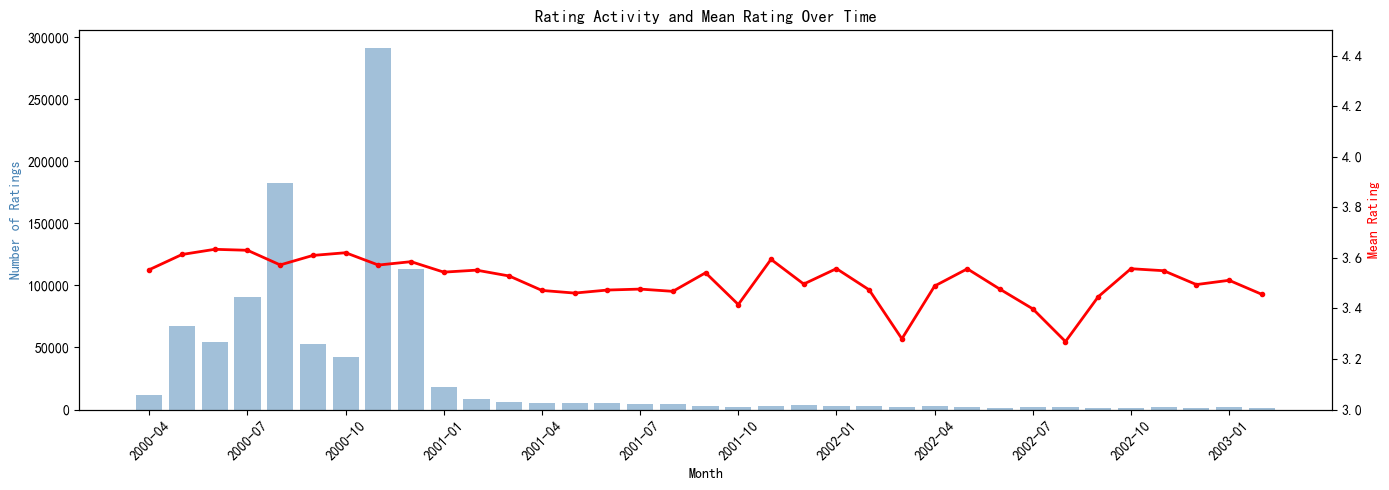

In [11]:
ratings_with_time = ratings.copy()
ratings_with_time['date'] = pd.to_datetime(ratings_with_time['timestamp'], unit='s')
ratings_with_time['month'] = ratings_with_time['date'].dt.to_period('M')

monthly = ratings_with_time.groupby('month').agg(
    count=('rating', 'count'),
    mean_rating=('rating', 'mean')
).reset_index()
monthly['month'] = monthly['month'].astype(str)

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.bar(range(len(monthly)), monthly['count'], alpha=0.5, color='steelblue', label='Rating Count')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Ratings', color='steelblue')

ax2 = ax1.twinx()
ax2.plot(range(len(monthly)), monthly['mean_rating'], color='red', linewidth=2, marker='o', markersize=3, label='Mean Rating')
ax2.set_ylabel('Mean Rating', color='red')
ax2.set_ylim(3.0, 4.5)

ax1.set_xticks(range(0, len(monthly), max(1, len(monthly)//10)))
ax1.set_xticklabels([monthly['month'].iloc[i] for i in range(0, len(monthly), max(1, len(monthly)//10))], rotation=45)
ax1.set_title('Rating Activity and Mean Rating Over Time')

plt.tight_layout()
fig.savefig(os.path.join(save_dir, 'rating_over_time.png'), dpi=300, bbox_inches='tight')
plt.show()

### 4.6 用户人口统计分析

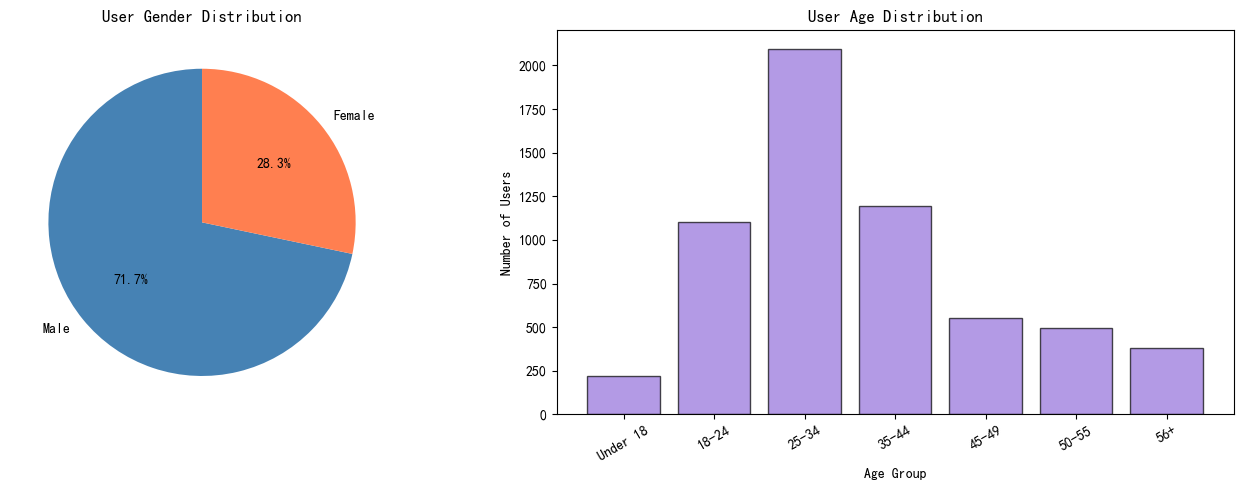

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 性别分布
gender_counts = users['gender'].value_counts()
axes[0].pie(gender_counts.values, labels=['Male' if g == 'M' else 'Female' for g in gender_counts.index],
            autopct='%1.1f%%', colors=['steelblue', 'coral'], startangle=90)
axes[0].set_title('User Gender Distribution')

# 年龄分布
age_map = {1: 'Under 18', 18: '18-24', 25: '25-34', 35: '35-44', 45: '45-49', 50: '50-55', 56: '56+'}
users['age_label'] = users['age'].map(age_map)
age_counts = users['age_label'].value_counts().reindex([age_map[k] for k in sorted(age_map.keys())])
axes[1].bar(range(len(age_counts)), age_counts.values, color='mediumpurple', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(age_counts)))
axes[1].set_xticklabels(age_counts.index, rotation=30)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Users')
axes[1].set_title('User Age Distribution')

plt.tight_layout()
fig.savefig(os.path.join(save_dir, 'user_demographics.png'), dpi=300, bbox_inches='tight')
plt.show()

## 5. 总结

### 关键发现
- MovieLens-1M 包含约 100 万条评分数据，覆盖 6,040 位用户和 3,883 部电影
- 数据稀疏度约为 95.5%，是典型的稀疏推荐场景
- 用户活跃度和电影热门度均呈长尾分布
- 评分以 4 分为主，整体偏正向
- Drama 和 Comedy 是最常见的电影类型
- 用户群体以 25-34 岁男性为主